# Ejercicio 3: Agente de inspección de calidad de productos

## Ficha PEAS

| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | Matriz de $5 \times 5$ píxeles de NumPy (`0` = píxel normal, `1` = píxel defectuoso) |
| **Acciones (A)** | `Aprobar`, `Revisión manual`, `Rechazar` |
| **Entorno (E)** | Línea de producción industrial con cámara de captura de imágenes |
| **Objetivo** | Clasificar correctamente los productos según la cantidad de defectos detectados |
| **Medida de desempeño (P)** | Porcentaje de productos clasificados correctamente y reducción de falsos aprobados |

---

## Justificación de las reglas

El agente analiza la matriz de $5 \times 5$ mediante el conteo total de píxeles defectuosos (`1`). Si el producto no presenta ningún defecto ($0$), se **aprueba** automáticamente para continuar en la línea. Si presenta de $1$ a $3$ píxeles defectuosos, se deriva a **revisión manual** para evaluar si es una pieza recuperable. Si supera los $3$ píxeles defectuosos, se **rechaza** directamente por exceder el límite de tolerancia de calidad.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy (0 = normal, 1 = defectuoso)
    Retorna una tupla: (accion, motivo)
    """
    defectos = np.sum(imagen == 1)
    
    if defectos == 0:
        return ("Aprobar", "No se detectaron pixeles defectuosos.")
    elif defectos <= 3:
        return ("Revision manual", f"Se detectaron {defectos} pixeles defectuosos; requiere evaluacion.")
    else:
        return ("Rechazar", f"Se detectaron {defectos} pixeles defectuosos; excede el limite permitido.")

Prueba 1: Aprobar -> No se detectaron pixeles defectuosos.


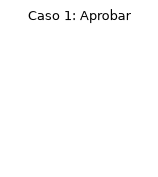

Prueba 2: Revision manual -> Se detectaron 1 pixeles defectuosos; requiere evaluacion.


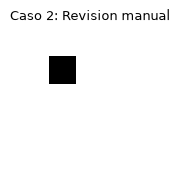

Prueba 3: Revision manual -> Se detectaron 3 pixeles defectuosos; requiere evaluacion.


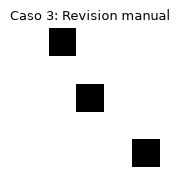

Prueba 4: Rechazar -> Se detectaron 4 pixeles defectuosos; excede el limite permitido.


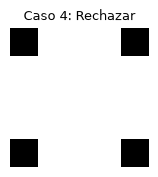

In [2]:
# --- PRUEBAS DEL AGENTE (Mínimo 4 matrices) ---

# Caso 1: 0 defectos (Aprobar)
img1 = np.zeros((5, 5), dtype=int)

# Caso 2: 1 defecto (Revisión manual)
img2 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
])

# Caso 3: 3 defectos (Límite superior para Revisión manual)
img3 = np.array([
    [0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1]
])

# Caso 4: 4 defectos (Límite inferior para Rechazar)
img4 = np.array([
    [1, 0, 0, 0, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [1, 0, 0, 0, 1]
])

casos = [img1, img2, img3, img4]

# Ejecución y visualización
for i, img in enumerate(casos, 1):
    accion, motivo = agente_inspeccion(img)
    print(f"Prueba {i}: {accion} -> {motivo}")
    
    plt.figure(figsize=(1.8, 1.8))
    plt.imshow(img, cmap="gray_r")
    plt.title(f"Caso {i}: {accion}", fontsize=9)
    plt.axis("off")
    plt.show()